# 질문 응답 충분성

In [6]:
import re
import kss
from pathlib import Path

SCRIPT_DIR = Path("/Users/parkdahyeon/Documents/my_ws/lecturesight/data")


def extract_timestamp_blocks(raw_text):
    pattern = re.compile(
        r"^\s*<(?P<timestamp>\d{2}:\d{2}:\d{2})>\s*"
        r"(?P<speaker>[a-f0-9]{8}):\s*"
        r"(?P<text>.*)\s*$",
        re.MULTILINE,
    )
    blocks = []
    for m in pattern.finditer(raw_text):
        text = m.group("text").strip()
        if text:
            blocks.append({"timestamp": m.group("timestamp"), "text": text})
    return blocks


# ============================================================
# 1. KSS 문장 분리
# ============================================================

all_file_sentences = {}

for file_path in sorted(SCRIPT_DIR.glob("*.txt")):
    raw = file_path.read_text(encoding="utf-8", errors="ignore")
    blocks = extract_timestamp_blocks(raw)
    full_text = " ".join(b["text"] for b in blocks if len(b["text"]) >= 8)
    sentences = kss.split_sentences(full_text, backend="auto")
    all_file_sentences[file_path.name] = sentences

    print(f"[{file_path.name[:10]}]  총 {len(sentences)}문장")
    for s in sentences[:10]:
        print(f"  {s}")
    print()


[Kss]: Oh! You have mecab in your environment. Kss will take this as a backend! :D



[2026-02-02]  총 1575문장
  여러분 오늘 수업 진행하도록 하겠습니다.
  저희가 이제 오늘 1차 잡바 마지막 날입니다.
  그래서 지난 시간에 제너릭 타입을 이용을 해서 커스텀 컬렉션을 활용한 크루드 방법을 학습 이해를 하고 그다음에 데이터 흐름 읽기 쓰기를 구현하는 날이에요.
  자바는 NIO 패키지가 있고 그 다음에 NIO2라는 패키지를 가지고 있는데, 이 NI2는 자바 하는 애들이에요.
  그래서 이걸 세 가지 섹션으로 나눠서 진행을 하고 있습니다.
  오늘 이런 것들을 조금 살펴보고 오후에는 효울씨 입실하기 전에 데이터베이스 설치하고 그 다음 오늘은 마무리하도록 조금 화면 전환 좀 할게요
  일단은 저희가 오늘 이제 수업할 내용은 자바 아이오 패키지가 이렇게 구현이 되어 있고 밑에 보시면 NIO 패키지가 이렇게 구현이 되어 있는 걸 볼 수가 있어요.
  지금 다양한 섹션으로 구현할 수가 있는데, 여기 보시면 잡아이오가 있고요.
  아이오 패키지가 있고 그다음에 밑에 보시면은 자바 NIO라는 패키지가 있죠.
  그 다음에 스트림 단위로 구현을 해주는 자바 NIO 여기 보면 파일이라고 하는 객체를 가지고 있는 패키지가 이렇게 세 가지가 있어요.

[2026-02-03]  총 2004문장
  한 해보도록 하겠습니다.
  출력 IO 개념 이해하고 프로그램에서 데이터 흐름 설명할 수 있다라고 했었는데 저 입출력 개념 자체가 프로그램이 있어 그러면 이제 외부 자원 콘솔 네트워크 이런 사이에제 데이터 이동 자체를 의미를 하는 거고, 자체가 입출력 I이O 자체가 그래서 나 이 아이O가 뭐야?
  이러면 프로그램하고 그 다음에부상 파이콘솔 네트워크 사이 데이터 이동하는 걸 얘기해 이렇게 간단하게 얘기하면 될 것 같고, 여기서 이제 인풋음에 아웃풋 이렇게 이 얘기를 하는데 인풋이라고 자체는 외부 데이터를 프로그램으로 읽어오는 것을 얘기하는 거고, 아웃풋의 출력이라고 하는 것은 프로그램의 데이터를 외부로 내보내는 것을 얘기를 하는 거예요.
  그리고 이 모

In [10]:
EXPLICIT_QUESTION_PATTERNS = [
    # 강사님 + 격식 어미
    r"강사님.{0,80}(해야\s*돼요|해야\s*되나요|해도\s*돼요|해도\s*되나요|써도\s*돼요|써도\s*되나요)",
    r"강사님.{0,80}(되나요|될까요|돼요|안\s*돼요|안\s*되나요|안\s*되는데요)",
    r"강사님.{0,80}(뭐예요|뭔가요|뭐죠|어떻게\s*해요|어떻게\s*하나요|왜\s*그래요|어디\s*있어요)",
    r"강사님.{0,80}(에러|오류|워닝|안\s*나와요|안\s*떠요)",
    # 강사님 + 구어체 어미
    r"강사님.{0,80}(이게\s*뭐야|뭐야|뭔데|거야|건가요|건데요)",
    r"강사님.{0,80}(어떡해|어쩌지|어쩌죠)",
    r"강사님.{0,80}(넣어봐도|해봐도|써봐도|봐도\s*돼)",
    r"강사님.{0,80}(하고\s*싶어|넣고\s*싶어|쓰고\s*싶어|하고\s*싶은데)",
    r"강사님.{0,80}없어요",
    r"강사님.{0,80}나요",
    r"강사님.{0,80}(지\s*않아|않아요|않는데요)",
    # 후치 강사님 (질문어 앞, 강사님 뒤)
    r"(어떻게|어디|왜).{0,80}강사님(?!이|들)",
    # 질문 명시
    r".{0,80}질문이\s*(있는데|들어왔는데|나왔는데|왔는데)",
    r".{0,80}질문을\s*(주셨는데|하셨는데|했는데)",
    r".{0,80}라고\s*질문",
    r".{0,80}라는\s*질문",
    r".{0,80}물어보셨는데",
    r".{0,80}물어보시는데",
    r".{0,80}여쭤보셨는데",
    r".{0,80}여쭤보시는데",
    r"(채팅|채팅창|DM|디엠).{0,50}(질문|올라왔|남겨|보내|주셨|주셨어)",
]

EXCLUDE_PATTERNS = [
    r"다른\s*강사님",
    r"나는\s*강사님",
]

explicit_q_re = re.compile("|".join(EXPLICIT_QUESTION_PATTERNS))
exclude_re    = re.compile("|".join(EXCLUDE_PATTERNS))

QA_ANSWER_WINDOW = 30  # 문장 수 기준


def is_question(text):
    if exclude_re.search(text):
        return False
    return bool(explicit_q_re.search(text))


def extract_qa_pairs(sentences):
    pairs = []
    for i, sent in enumerate(sentences):
        if not is_question(sent):
            continue

        answer_sentences = []
        for s in sentences[i + 1 : i + 1 + QA_ANSWER_WINDOW]:
            if is_question(s):
                break
            answer_sentences.append(s)

        pairs.append({
            "question": sent,
            "answer": " ".join(answer_sentences),
            "answer_sentences": len(answer_sentences),
            "answer_sentences_list": answer_sentences,
            "answer_chars": len(" ".join(answer_sentences)),
        })
    return pairs


# ============================================================
# 2. Q-A 탐지
# ============================================================

all_pairs = {}
total_pairs = 0

for file_name, sentences in all_file_sentences.items():
    pairs = extract_qa_pairs(sentences)
    all_pairs[file_name[:10]] = pairs
    total_pairs += len(pairs)

    print(f"[{file_name[:10]}]  총 {len(pairs)}개")
    for p in pairs[:3]:
        print(f"  Q: {p['question'][:80]}")
        print(f"  A ({p['answer_sentences']}문장): {p['answer'][:100]}")
        print()

print(f"전체 Q-A 페어: {total_pairs}개")


[2026-02-02]  총 0개
[2026-02-03]  총 6개
  Q: 어제 안 되시는 분들은 DM 보내셔가지고, 몇 분 제가 회신은 드렸는데 뭐 없으시 해고팀에서 확인하시고 다 만드시 설치된 거 일단 탐색기 열어서
  A (30문장): 윈도우에서 뒤에 설치를 하시게 되면 커버 자체가 관리자 권한으로 설치가 안 되지 빼고 하지 그러니까 왠만하면 시에 설치하시는 게 좋다. 서버는 권한 설치할 때 살짝살짝 그리고 데이

  Q: 그 설치 등등 이런 DM 보내실 때토님한테 같이 보내세요.
  A (30문장): 아니면 수업 그래 저 회신이 빨라 아니면 수업 관련 질의응 올려주고 계시는데 네 거기다 같이 해주셔도 상관없습니다. 혹시 8.0.45를 설치해야L 마큐L80이 서비스로 올라오는 게

  Q: 여러분들 프로그램 설치하면 강사님 이거 돼요.
  A (30문장): 안 돼요. 나한테 엔터프라이즈를 설치를 하게 되면 오라클에서 가서 기술 지원을 해줘 이건 이렇게 쓰는 거고, 이건 이렇게 쓰는 거고, 이건 언제 업데이트가 되는 거고, 이런 식으로

[2026-02-04]  총 2개
  Q: 데이터베이스 자체는 얘네가 점 이거 하나당 파일 하나로 인지를 하고 저희 같은 경우에 얘가 이제 IBD라고 하는 파일로 하나씩 생성이 된다까지 
  A (30문장): 원형은 똑같지만 안에 들어가는 이 내용이 조금 달라요. DB마다 왜냐하면, 벤더사가 자기들만의 어떤 아이템들이 있겠지 그렇죠. 우리는 DB가 파일로 노출이 되고 그 파일 안에 인덱

  Q: 이렇게 자동으로 만들고 이름 주고 여기 다 자동으로 올라와 그래서 8.4엔I X2 눌러서티뉴 하고 그다음에 커넥션 이름이 있으니까 여기는 또 테
  A (30문장): 뭐 여기 테스트 클래스 연결 객체 하나 있죠면 여기다가 딜리트 하시면 돼요. 없어지겠 따르륵 없어지죠 오케이 클로즈 하시 그 다음에 여기서 오른쪽 마우스 누르면 여기서도 오픈 에디

[2026-02-05]  총 3개
  Q: 강사님 여기서 가장 많이 쓰는 게 뭐예요

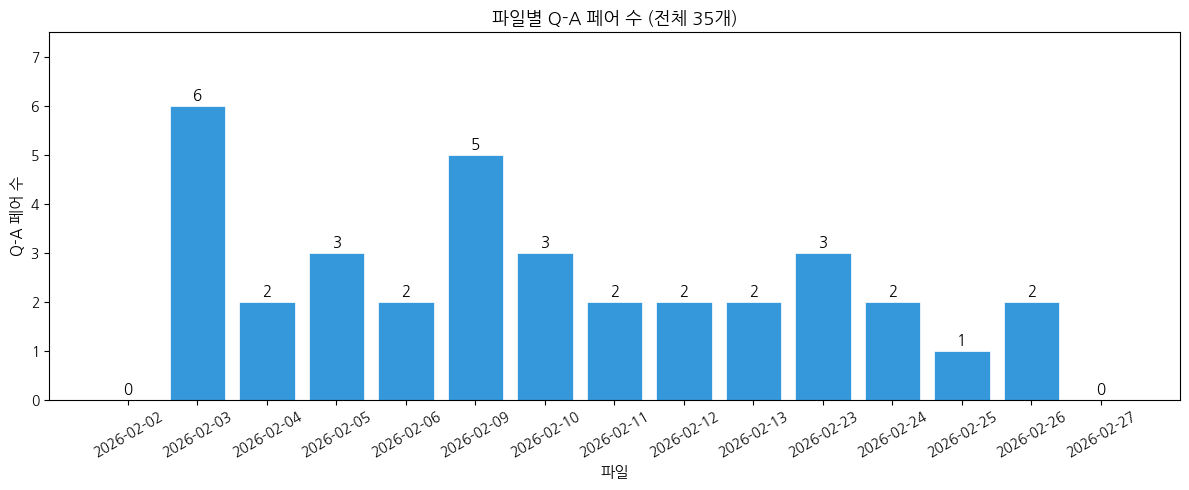

총 35개  |  평균 2.3개/파일  |  0개 파일: 2개


In [11]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

for font in fm.findSystemFonts():
    if any(k in font for k in ["AppleGothic", "NanumGothic", "Malgun", "NotoSansCJK"]):
        plt.rcParams["font.family"] = fm.FontProperties(fname=font).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 3. Q-A 페어 수 분포 시각화
# ============================================================

files = list(all_pairs.keys())
counts = [len(v) for v in all_pairs.values()]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(files, counts, color="#3498db", edgecolor="white", linewidth=0.5)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(count), ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xlabel("파일", fontsize=11)
ax.set_ylabel("Q-A 페어 수", fontsize=11)
ax.set_title(f"파일별 Q-A 페어 수 (전체 {sum(counts)}개)", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(counts) + 1.5)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"총 {sum(counts)}개  |  평균 {sum(counts)/len(counts):.1f}개/파일  |  0개 파일: {sum(1 for c in counts if c==0)}개")


In [12]:
# ============================================================
# 4. Q-A 페어 전체 보기 (full version)
# ============================================================

for file_name, pairs in all_pairs.items():
    if not pairs:
        continue
    print(f"{'='*60}")
    print(f"[{file_name}]  {len(pairs)}개 Q-A 페어")
    print(f"{'='*60}")
    for i, p in enumerate(pairs, 1):
        print(f"\n── Q{i} {'─'*50}")
        print(f"Q: {p['question']}")
        print(f"\nA ({p['answer_sentences']}문장, {p['answer_chars']}자):")
        for j, s in enumerate(p["answer_sentences_list"], 1):
            print(f"  {j:>2}. {s}")
    print()


[2026-02-03]  6개 Q-A 페어

── Q1 ──────────────────────────────────────────────────
Q: 어제 안 되시는 분들은 DM 보내셔가지고, 몇 분 제가 회신은 드렸는데 뭐 없으시 해고팀에서 확인하시고 다 만드시 설치된 거 일단 탐색기 열어서 확인하도록 하겠습니다시 드라이브 오셔가지고, 뒤에 설치하신 분들도 있는데, 뒤에 설치를 하시게 되면 C 드라이브가 관리자 권한으로 설치가 자동으로 되는 폴더이거든요.

A (30문장, 1412자):
   1. 윈도우에서 뒤에 설치를 하시게 되면 커버 자체가 관리자 권한으로 설치가 안 되지 빼고 하지
   2. 그러니까 왠만하면 시에 설치하시는 게 좋다.
   3. 서버는 권한 설치할 때 살짝살짝 그리고 데이터베이스 마이QL은 일반적인 DB 정형 DB는가 데이터를 설치를 하잖아요.
   4. 이건 알고 가셔야 돼 그림 못 그리지만 하나만 내가 사용하고 있는 OS야
   5. 얘가 줌이 아니라 가지고 이 풀이 좀 이쁘지가 않아 이거 딥이야
   6. 이렇게 내 내가 사용하고 있는 OS야
   7. 이렇게 하고 있어요.
   8. 여기가 지금 현재 C1 클라이언트가 내 OS 내 PC에 접속을 안 접속을 CNC로 하게 되면 그냥 접속이 아니고 일단은 주소 접속이 이루어져요
   9. 클라이언트 여기는 서버 내 OS 이거 내꺼 I OS DB인데 우리는 이 OS의 C 드라이브에 프로그램 파일즈를 통해서 데이터베이스를 설치했다고 생각하지만 마이에스큐L은 전혀 그렇게 생각 안 해요.
  10. 몸은 너한테 줬지만 나는 서버야
  11. 이렇게 그래서 마이에스펠에 설치했던 프로그램이 뭐냐면 실제 OS에서 언한를 받아가지고, DB 서버를 단독으로 설치할 수 있게끔 해서 이 서버가 하나 돌아가는 형태예요.
  12. 이해하죠.
  13. 이렇게 상태로 이 서버가 실행을 할 때 그냥 실행하는 게 아니라 내가 얘기하잖아.
  14. 몸은 너한테 있지만 나는 단독 실행이야
  15. 이렇게 네